In [37]:
import pandas as pd
import numpy as np
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns



In [38]:
# Load dataset
df = pd.read_csv("diabetes_dataset_with_notes.csv")

#load dataset
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(":", "_")
      .str.replace("-", "_")
      .str.replace(" ", "_")
)

#drop location
df = df.drop(columns=['location'])


In [39]:
# reencode gender and smoking history
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0, 'Other' : 2})
df['smoking_history'] = df['smoking_history'].str.lower().str.replace(" ", "_")
df = pd.get_dummies(df, columns=['smoking_history'], drop_first=True)

# check
print("Columns:", df.columns.tolist())


Columns: ['year', 'gender', 'age', 'race_africanamerican', 'race_asian', 'race_caucasian', 'race_hispanic', 'race_other', 'hypertension', 'heart_disease', 'bmi', 'hba1c_level', 'blood_glucose_level', 'diabetes', 'clinical_notes', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_no_info', 'smoking_history_not_current']


In [40]:
# Identify non-numeric columns
text_columns = df.select_dtypes(include='object').columns
print("Dropping text columns:", text_columns.tolist())

df = df.drop(columns=text_columns)

Dropping text columns: ['clinical_notes']


In [41]:
df.columns.tolist()


['year',
 'gender',
 'age',
 'race_africanamerican',
 'race_asian',
 'race_caucasian',
 'race_hispanic',
 'race_other',
 'hypertension',
 'heart_disease',
 'bmi',
 'hba1c_level',
 'blood_glucose_level',
 'diabetes',
 'smoking_history_ever',
 'smoking_history_former',
 'smoking_history_never',
 'smoking_history_no_info',
 'smoking_history_not_current']

In [52]:
feature_names = df.columns.drop("diabetes")

X = df[feature_names]
y = df["diabetes"]

X.head()




,year,gender,age,race_africanamerican,race_asian,race_caucasian,race_hispanic,race_other,hypertension,heart_disease,bmi,hba1c_level,blood_glucose_level,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_no_info,smoking_history_not_current
0,2020,0,32.0,0,0,0,0,1,0,0,27.32,5.0,100,False,False,True,False,False
1,2015,0,29.0,0,1,0,0,0,0,0,19.95,5.0,90,False,False,True,False,False
2,2015,1,18.0,0,0,0,0,1,0,0,23.76,4.8,160,False,False,True,False,False
3,2015,1,41.0,0,0,1,0,0,0,0,27.32,4.0,159,False,False,True,False,False
4,2016,0,52.0,1,0,0,0,0,0,0,23.75,6.5,90,False,False,True,False,False


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=feature_names)
df_scaled["diabetes"] = y

df_scaled.head()



,year,gender,age,race_africanamerican,race_asian,race_caucasian,race_hispanic,race_other,hypertension,heart_disease,bmi,hba1c_level,blood_glucose_level,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_no_info,smoking_history_not_current,diabetes
0,1.218511,-0.841047,-0.439045,-0.503482,-0.500234,-0.498062,-0.498249,2.000125,-0.284439,-0.202578,-0.000116,-0.492690,-0.934905,-0.20423,-0.321198,1.35993,-0.747008,-0.262512,0
1,-2.498320,-0.841047,-0.572279,-0.503482,1.999063,-0.498062,-0.498249,-0.499969,-0.284439,-0.202578,-1.110599,-0.492690,-1.180558,-0.20423,-0.321198,1.35993,-0.747008,-0.262512,0
2,-2.498320,1.187234,-1.060805,-0.503482,-0.500234,-0.498062,-0.498249,2.000125,-0.284439,-0.202578,-0.536523,-0.679490,0.539009,-0.20423,-0.321198,1.35993,-0.747008,-0.262512,0
3,-2.498320,1.187234,-0.039342,-0.503482,-0.500234,2.007783,-0.498249,-0.499969,-0.284439,-0.202578,-0.000116,-1.426688,0.514444,-0.20423,-0.321198,1.35993,-0.747008,-0.262512,0
4,-1.754954,-0.841047,0.449184,1.986168,-0.500234,-0.498062,-0.498249,-0.499969,-0.284439,-0.202578,-0.538029,0.908306,-1.180558,-0.20423,-0.321198,1.35993,-0.747008,-0.262512,0


In [54]:
from sklearn.model_selection import train_test_split

X_full = df_scaled[feature_names]
y_full = df_scaled["diabetes"]

X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)


In [55]:
from sklearn.linear_model import LogisticRegression

model_full = LogisticRegression(max_iter=1000)
model_full.fit(X_full_train, y_full_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [56]:
from sklearn.metrics import confusion_matrix

y_full_pred = model_full.predict(X_full_test)

tn, fp, fn, tp = confusion_matrix(y_full_test, y_full_pred).ravel()
fpr_full = fp / (fp + tn)

print("FPR (Full dataset):", fpr_full)



FPR (Full dataset): 0.00912568306010929


In [57]:
df_women = df_scaled[df["gender"] == 0]

X_women = df_women[feature_names]
y_women = df_women["diabetes"]



In [58]:
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_women, y_women, test_size=0.2, random_state=42, stratify=y_women
)


In [59]:
model_women = LogisticRegression(max_iter=1000)
model_women.fit(Xw_train, yw_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [60]:
y_women_pred = model_women.predict(Xw_test)

tn, fp, fn, tp = confusion_matrix(yw_test, y_women_pred).ravel()
fpr_women = fp / (fp + tn)

print("FPR (Women only):", fpr_women)


FPR (Women only): 0.007024678805804603


In [61]:
df_men = df_scaled[df["gender"] == 1]

X_men = df_men[feature_names]
y_men = df_men["diabetes"]


In [62]:
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_men, y_men, test_size=0.2, random_state=42, stratify=y_men
)


In [63]:
model_men = LogisticRegression(max_iter=1000)
model_men.fit(Xm_train, ym_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [64]:
y_men_pred = model_men.predict(Xm_test)

tn, fp, fn, tp = confusion_matrix(ym_test, y_men_pred).ravel()
fpr_men = fp / (fp + tn)

print("FPR (Men only):", fpr_men)


FPR (Men only): 0.01190157796202193


In [65]:
print("==================================")
print("FPR (Full dataset):", fpr_full)
print("FPR (Women only):  ", fpr_women)
print("FPR (Men only):    ", fpr_men)
print("==================================")

if fpr_women > fpr_men:
    print("Women have a HIGHER false positive rate → potential bias.")
else:
    print("Women do NOT have a higher false positive rate.")


FPR (Full dataset): 0.00912568306010929
FPR (Women only):   0.007024678805804603
FPR (Men only):     0.01190157796202193
Women do NOT have a higher false positive rate.


In [66]:
from sklearn.metrics import confusion_matrix

def get_rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn)
    tpr = tp / (tp + fn)
    return fpr, tpr

fpr_full, tpr_full = get_rates(y_full_test, model_full.predict(X_full_test))
fpr_women, tpr_women = get_rates(yw_test, model_women.predict(Xw_test))
fpr_men, tpr_men = get_rates(ym_test, model_men.predict(Xm_test))

print("TPR (Full): ", tpr_full)
print("TPR (Women):", tpr_women)
print("TPR (Men):  ", tpr_men)


TPR (Full):  0.6352941176470588
TPR (Women): 0.624439461883408
TPR (Men):   0.6101485148514851


In [67]:
eo_full = abs(tpr_women - tpr_men) + abs(fpr_women - fpr_men)
print("Equalized Odds Score:", eo_full)


Equalized Odds Score: 0.019167846188140235


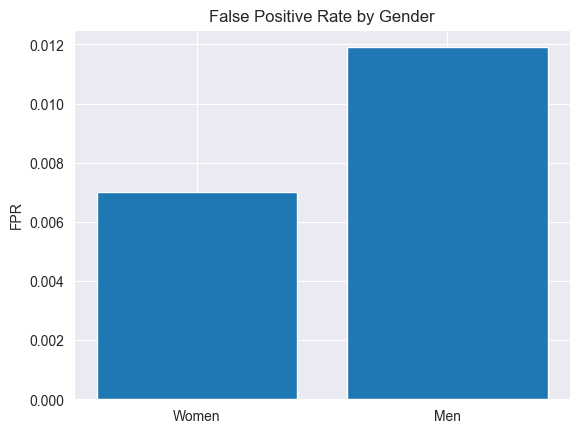

In [68]:
import matplotlib.pyplot as plt

groups = ['Women', 'Men']
fprs = [fpr_women, fpr_men]

plt.bar(groups, fprs)
plt.title("False Positive Rate by Gender")
plt.ylabel("FPR")
plt.show()


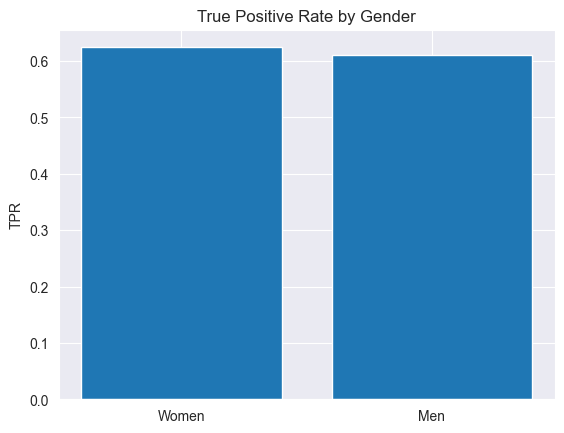

In [69]:
tprs = [tpr_women, tpr_men]

plt.bar(groups, tprs)
plt.title("True Positive Rate by Gender")
plt.ylabel("TPR")
plt.show()


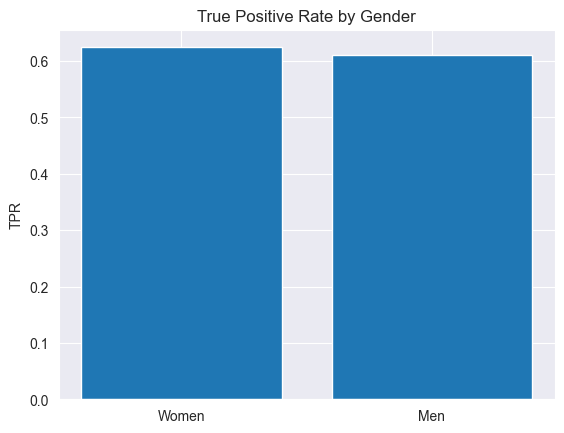

In [70]:
tprs = [tpr_women, tpr_men]

plt.bar(groups, tprs)
plt.title("True Positive Rate by Gender")
plt.ylabel("TPR")
plt.show()


In [74]:
import pandas as pd
from sklearn.metrics import confusion_matrix

# Helper function to compute TPR/FPR
def compute_rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn)
    tpr = tp / (tp + fn)
    return fpr, tpr

# Get FPR & TPR for each group
fpr_full, tpr_full = compute_rates(y_full_test, model_full.predict(X_full_test))
fpr_women, tpr_women = compute_rates(yw_test, model_women.predict(Xw_test))
fpr_men, tpr_men = compute_rates(ym_test, model_men.predict(Xm_test))

# Disparate Impact (based on Positive Prediction Rate)
ppr_women = model_women.predict(Xw_test).mean()
ppr_men   = model_men.predict(Xm_test).mean()
disparate_impact = ppr_women / ppr_men if ppr_men > 0 else float("inf")

# Equalized Odds Score
equalized_odds = abs(tpr_women - tpr_men) + abs(fpr_women - fpr_men)

# Create summary table
summary_df = pd.DataFrame({
    "Group": ["Full", "Women", "Men"],
    "FPR":   [fpr_full, fpr_women, fpr_men],
    "TPR":   [tpr_full, tpr_women, tpr_men],
    "PPR":   [model_full.predict(X_full_test).mean(), ppr_women, ppr_men]
})

print("=== Fairness Summary Table ===")
display(summary_df.round(4))

print("\nEqualized Odds Score:", round(equalized_odds, 6))
print("Disparate Impact Ratio (Women/Men):", round(disparate_impact, 4))

# Interpret fairness automatically
print("\n=== Fairness Interpretation ===")

if abs(fpr_women - fpr_men) < 0.02:
    print("✔ FPR difference is very small → No harmful false-positive bias.")
else:
    print("⚠ FPR difference is noticeable → Potential unfairness in false positives.")

if abs(tpr_women - tpr_men) < 0.02:
    print("✔ TPR difference is very small → Equal opportunity is satisfied.")
else:
    print("⚠ Large TPR difference → Unequal opportunity.")

if equalized_odds < 0.05:
    print("✔ Equalized Odds is low → Model is generally fair.")
else:
    print("⚠ Equalized Odds is high → Model treats groups differently.")

if 0.8 <= disparate_impact <= 1.25:
    print("✔ Disparate Impact within acceptable range (80–125%).")
else:
    print("⚠ Disparate Impact outside acceptable range → Possible adverse impact.")

print("\n=== Final Conclusion ===")

if (abs(fpr_women - fpr_men) < 0.02
    and abs(tpr_women - tpr_men) < 0.02
    and equalized_odds < 0.05):
    print("Overall, the model does NOT show evidence of gender bias.")
else:
    print("⚠ Some fairness metrics indicate unequal treatment between genders.")


=== Fairness Summary Table ===


,Group,FPR,TPR,PPR
0,Full,0.0091,0.6353,0.0624
1,Women,0.0070,0.6244,0.0541
2,Men,0.0119,0.6101,0.0702



Equalized Odds Score: 0.019168
Disparate Impact Ratio (Women/Men): 0.7695

=== Fairness Interpretation ===
✔ FPR difference is very small → No harmful false-positive bias.
✔ TPR difference is very small → Equal opportunity is satisfied.
✔ Equalized Odds is low → Model is generally fair.
⚠ Disparate Impact outside acceptable range → Possible adverse impact.

=== Final Conclusion ===
Overall, the model does NOT show evidence of gender bias.
